In [1]:
import pydpeet as eet
import matplotlib.pyplot as plt

In [2]:
Data = eet.convert_file(config = 'Neware', input_path = r"..\..\res\raw\Cal_Ageing_Checkup1.xlsx")

converting file to pandas DataFrame...
Reading sheets from ..\..\res\raw\Cal_Ageing_Checkup1.xlsx...
hadling record auxvol auxtemp sheets...
checking if headers need to be reindexed...
reindexing headers...
merging record and auxvol...
Handling sheets cycle, step and test...
merging cycle and step...
handling test sheet...
merging cycle_step_test and test...
checking if headers need to be reindexed...
reindexing headers...
merging record_auxvol and auxtemp...


C:\Users\Anton\Nextcloud\Organisation\Arbeit\Projekte\PyDPEET\pydpeet_dev\pydpeet\src\pydpeet\convert\zyklisierer\neware\reader.py:280: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_auxvol.rename(columns={'Date': 'Date - auxVol', 'DataPoint': 'DataPoint - auxVol'}, inplace=True)
C:\Users\Anton\Nextcloud\Organisation\Arbeit\Projekte\PyDPEET\pydpeet_dev\pydpeet\src\pydpeet\convert\zyklisierer\neware\reader.py:286: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_auxtemp.rename(columns={'Date': 'Date - auxTemp', 'DataPoint': 'DataPoint - auxTemp'}, inplace=True)


handling final merge...
mapping columns...
dropping additional data...
adding metadata to Dataframe...
Getting columns in correct order...
Checking for duplicate extra columns...
Selecting and ordering standard columns...
Selecting extra columns...
Combining standard and extra columns...
Reordered DataFrame columns!
Starting to fix data format...
Using formatter for config: Config.Neware
Data format fixed.
convert_file executed in 9.693320 seconds


In [7]:
Sequenced_Data = eet.process.sequence.step_analyzer.step_analyzer_primitives(Data)
Sequenced_Data.head()

Input Warning: Using EXAMPLE_STEP_ANALYZER_PRIMITIVES_CONFIG as fallback configuration. Manual Parameters will be kept.
Input Warning: Dropping NaN values in 'Testtime[s]', dropping duplicates and sorting 'Testtime[s]' column.
    0.2286s precompiling step_analyzer_primitives and df_primitives_correction
detecting segments in dataframe of size 163770...
    0.0025s calculating Power[W]
    0.0025s separating Voltage[V] into segments using incremental linear fit
    0.0022s separating Current[A] into segments using incremental linear fit
    0.0023s separating Power[W] into segments using incremental linear fit
    0.0044s adding Length_Segment_Voltage[V] to calculate the dominating segments
    0.0046s adding Length_Segment_Current[A] to calculate the dominating segments
    0.0036s adding Length_Segment_Power[W] to calculate the dominating segments
    0.0133s suppressing smaller segments
    0.0666s attempting to merge neighboring segments
    0.1217s fine tuning width of constant se

,Metadata,StepID,Voltage[V],Current[A],Temperature[°C],Testtime[s],Absolute Time[yyyy-mm-dd hh:mm:ss],EISFreq[Hz],Zre[Ohm],Zim[Ohm],...,ID,Variable,Duration,Length,Min,Max,Avg,Type,Direction,Slope
0.0,20240201100904-CheckUp-3-7-AM23NMC00009.xlsx U...,0,3.5269,1.4378,27.8,0.0,2024-02-01 10:09:04,None,None,None,...,1,V,9112,9111.0,3.5269,4.2001,3.889836,Ramp,Up,0.000074
1.0,None,0,3.5287,1.4398,27.8,1.0,2024-02-01 10:09:05,None,None,None,...,1,V,9112,9111.0,3.5269,4.2001,3.889836,Ramp,Up,0.000074
2.0,None,0,3.5298,1.4400,27.8,2.0,2024-02-01 10:09:06,None,None,None,...,1,V,9112,9111.0,3.5269,4.2001,3.889836,Ramp,Up,0.000074
3.0,None,0,3.5307,1.4400,27.8,3.0,2024-02-01 10:09:07,None,None,None,...,1,V,9112,9111.0,3.5269,4.2001,3.889836,Ramp,Up,0.000074
4.0,None,0,3.5315,1.4401,27.8,4.0,2024-02-01 10:09:08,None,None,None,...,1,V,9112,9111.0,3.5269,4.2001,3.889836,Ramp,Up,0.000074


In [5]:
Battery_Config = eet.process.analyze.am23nmc



# todo: is it possible to probide acces to the Batemo/About-Energy database and fetch battery configs directly from there?
# todo: or we download it and provide the databse directly?

Data = eet.process.analyze.add_capacity(Data, Sequenced_Data, config=Battery_Config) # todo: fix

analyzing segments...
    0.0080s filtering by ID
    0.0135s tag simple segments
    0.0354s tag sequences
    0.2448s assign longest sequence
    0.0015s separate sequences and df_with_segments
 Input Warning: Using default standard columns: ['Testtime[s]', 'Voltage[V]', 'Current[A]', 'Power[W]'] 
 Input Warning: Using default standard columns: ['Testtime[s]', 'Voltage[V]', 'Current[A]', 'Power[W]'] 


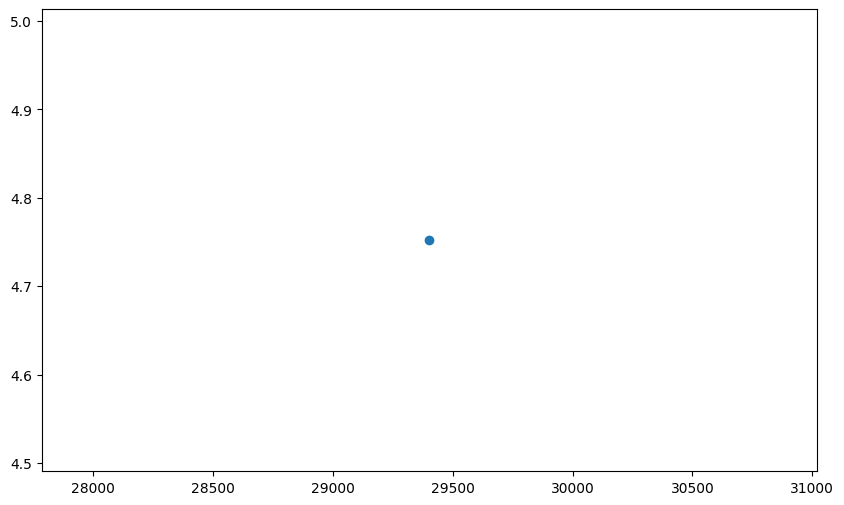

In [10]:
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(Data['Testtime[s]'], Data['Capacity[Ah]'])